# A frota de Uberlândia em 2026 (RENAVAM)

Quantos veículos a cidade tem, qual a idade da frota, quais marcas e modelos dominam as ruas.

Fonte: registro nacional de veículos (RENAVAM), dados abertos do Ministério dos Transportes, referência julho de 2026. O arquivo original cobre o Brasil inteiro; aqui uso só as linhas de Uberlândia.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print('ok')

ok


## 2. Carregar os dados

O arquivo `dados/frota_uberlandia_202607.csv` já está filtrado para a cidade. Cada linha é uma combinação de marca, modelo e ano de fabricação, com a quantidade de veículos registrados. O passo a passo do download e do filtro está no README da pasta.

In [2]:
df = pd.read_csv('dados/frota_uberlandia_202607.csv')
df['ano'] = pd.to_numeric(df['Ano Fabricação Veículo CRV'], errors='coerce')
df['qtd'] = df['Qtd. Veículos']

total = df['qtd'].sum()
print(f'{total:,.0f} veículos registrados em Uberlândia'.replace(',', '.'))
df.head(3)

565.639 veículos registrados em Uberlândia


,UF,Município,Marca Modelo,Ano Fabricação Veículo CRV,Qtd. Veículos,ano,qtd
0,MINAS GERAIS,UBERLANDIA,A.FRAGA/F.PROPRIA TRICIC,2006,1.0,2006.0,1.0
1,MINAS GERAIS,UBERLANDIA,AGRALE,1983,2.0,1983.0,2.0
2,MINAS GERAIS,UBERLANDIA,AGRALE,1985,3.0,1985.0,3.0


## 3. Quantos veículos por habitante

Cruzando com a população do Censo 2022 (713.224 pessoas).

In [3]:
populacao = 713_224
per_capita = total / populacao
print(f'{per_capita:.2f} veículo por habitante')
print(f'ou {total / populacao * 1000:.0f} veículos para cada mil pessoas')

0.79 veículo por habitante
ou 793 veículos para cada mil pessoas


## 4. A idade da frota

Distribuição por ano de fabricação.

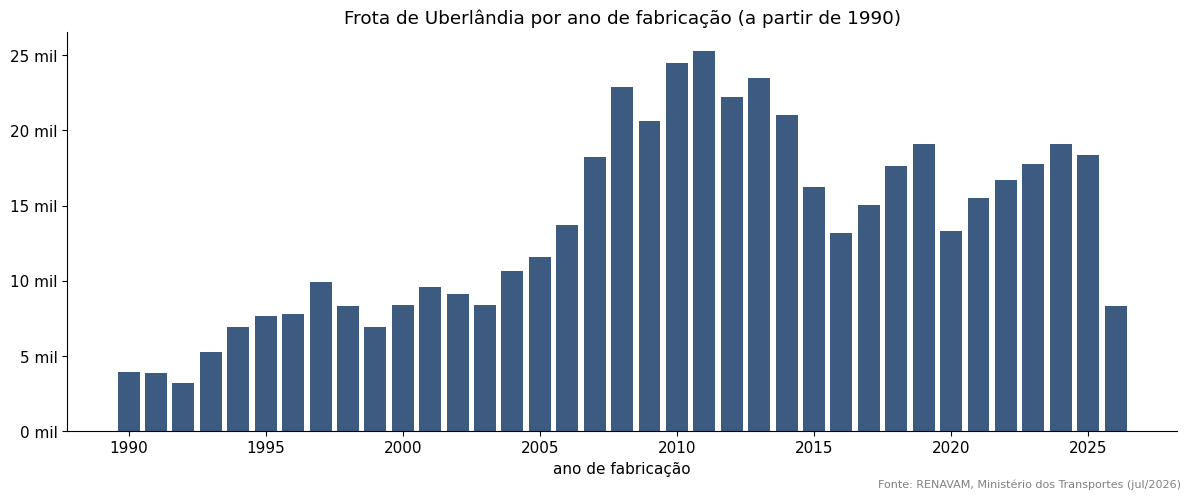

ano mediano da frota: 2010 (idade mediana de 16 anos)
14.2% da frota tem até 4 anos (2022 em diante)
50.0% da frota tem 16 anos ou mais (2010 para trás)


In [4]:
por_ano = df.dropna(subset=['ano']).groupby('ano')['qtd'].sum().sort_index()
por_ano = por_ano[por_ano.index >= 1990]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(por_ano.index.astype(int), por_ano.values, color='#3d5a80')
ax.set_title('Frota de Uberlândia por ano de fabricação (a partir de 1990)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f} mil'.replace(',', '.')))
ax.set_xlabel('ano de fabricação')
fig.text(0.99, 0.01, 'Fonte: RENAVAM, Ministério dos Transportes (jul/2026)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/frota_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()

com_ano = df.dropna(subset=['ano'])
mediana_ano = com_ano['ano'].median()
idade_mediana = 2026 - mediana_ano
recentes = com_ano[com_ano['ano'] >= 2022]['qtd'].sum() / total * 100
antigos = com_ano[com_ano['ano'] <= 2010]['qtd'].sum() / total * 100
print(f'ano mediano da frota: {mediana_ano:.0f} (idade mediana de {idade_mediana:.0f} anos)')
print(f'{recentes:.1f}% da frota tem até 4 anos (2022 em diante)')
print(f'{antigos:.1f}% da frota tem 16 anos ou mais (2010 para trás)')

## 5. As marcas que dominam

O campo de marca vem junto com o modelo, no formato MARCA/MODELO. Prefixos especiais: I/ é importado, R/ é reboque. Limpo isso antes de contar.

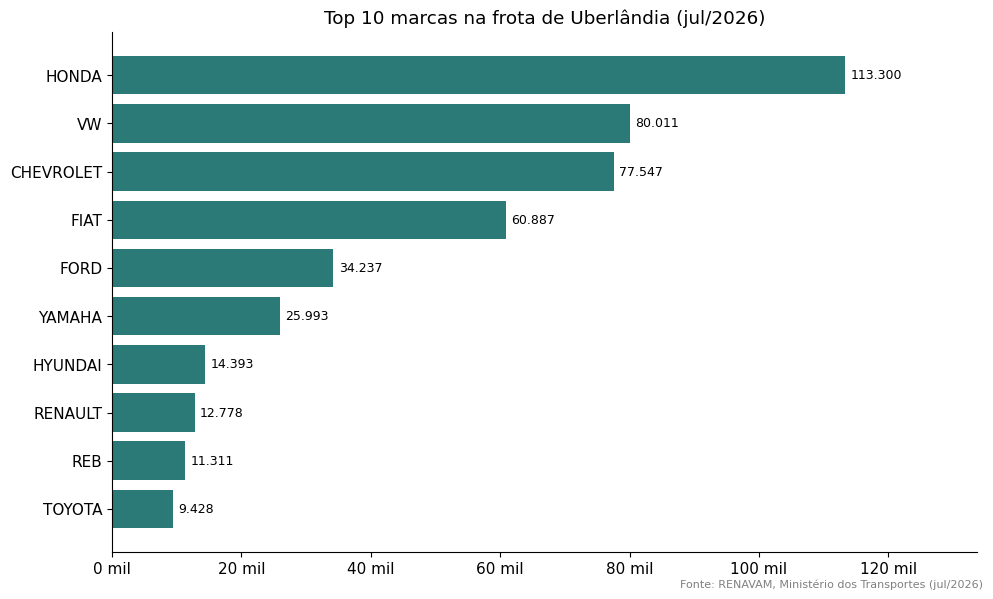

Honda sozinha é 20.0% da frota


In [5]:
def extrai_marca(mm):
    mm = str(mm)
    for prefixo in ('I/', 'R/'):
        if mm.startswith(prefixo):
            mm = mm[2:]
    marca = mm.split('/')[0].strip().upper()
    # junta variações do mesmo fabricante
    if marca in ('GM', 'CHEV', 'CHEVROLET'):
        return 'CHEVROLET'
    if marca in ('VW', 'VOLKSWAGEN'):
        return 'VW'
    if marca in ('M.BENZ', 'MERCEDES-BENZ', 'MBENZ'):
        return 'MERCEDES-BENZ'
    return marca

df['marca'] = df['Marca Modelo'].apply(extrai_marca)
top_marcas = df.groupby('marca')['qtd'].sum().sort_values(ascending=False).head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_marcas.index, top_marcas.values, color='#2b7a78')
ax.set_title('Top 10 marcas na frota de Uberlândia (jul/2026)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f} mil'.replace(',', '.')))
for i, v in enumerate(top_marcas.values):
    ax.text(v + 800, i, f'{v:,.0f}'.replace(',', '.'), va='center', fontsize=9)
ax.set_xlim(0, top_marcas.max() * 1.18)
fig.text(0.99, 0.01, 'Fonte: RENAVAM, Ministério dos Transportes (jul/2026)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/top_marcas.png', dpi=150, bbox_inches='tight')
plt.show()

honda_pct = df[df['marca'] == 'HONDA']['qtd'].sum() / total * 100
print(f'Honda sozinha é {honda_pct:.1f}% da frota')

## 6. Os modelos mais comuns

Aqui dá para ver o peso das motos: CG, Biz e Bros são modelos de motocicleta da Honda.

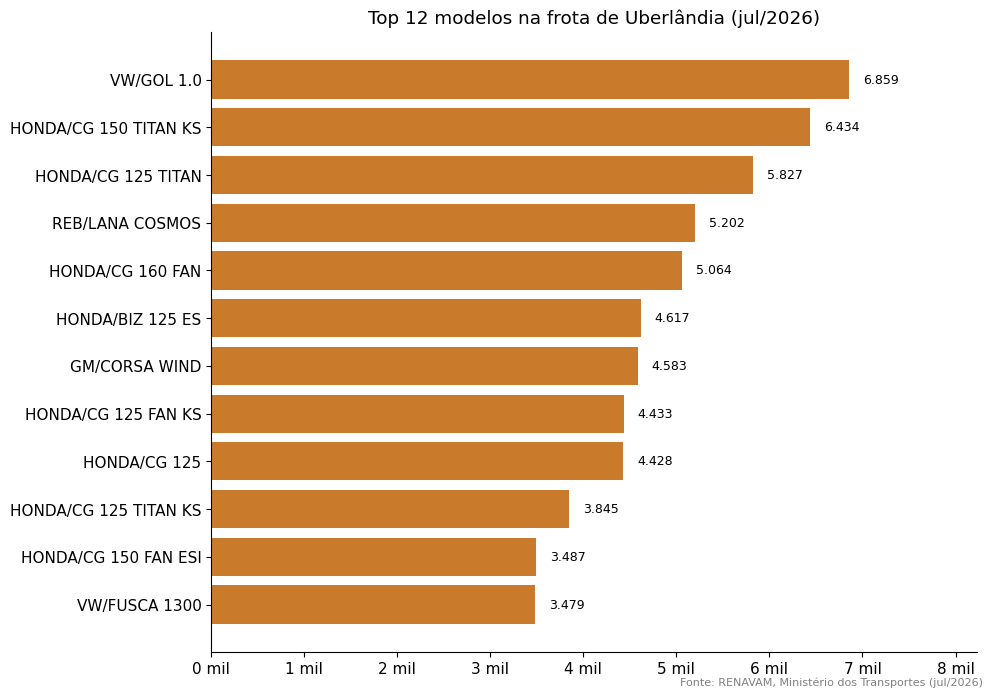

In [6]:
top_modelos = df.groupby('Marca Modelo')['qtd'].sum().sort_values(ascending=False).head(12).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_modelos.index, top_modelos.values, color='#c97b2b')
ax.set_title('Top 12 modelos na frota de Uberlândia (jul/2026)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f} mil'.replace(',', '.')))
for i, v in enumerate(top_modelos.values):
    ax.text(v + 150, i, f'{v:,.0f}'.replace(',', '.'), va='center', fontsize=9)
ax.set_xlim(0, top_modelos.max() * 1.2)
fig.text(0.99, 0.01, 'Fonte: RENAVAM, Ministério dos Transportes (jul/2026)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/top_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. O que eu tiro disso

Uberlândia tinha **565.639 veículos registrados** em julho de 2026, quase 0,8 veículo por habitante (793 para cada mil pessoas, usando a população do Censo 2022). É uma cidade motorizada.

Três coisas me chamaram atenção:

1. **A frota é velha.** O ano mediano de fabricação é 2010. Metade dos veículos tem 16 anos ou mais e só 14% têm até 4 anos.
2. **A moto manda na cidade.** A Honda sozinha é 20% da frota (113 mil veículos) e o ranking de modelos explica por quê: das 12 posições, 8 são motos Honda das famílias CG e Biz. O carro mais comum é o Gol 1.0, com 6.859 unidades.
3. **O Fusca não morre.** Ainda há 3.479 Fuscas 1300 rodando em Uberlândia, modelo que saiu de linha nos anos 80. Soma-se a isso os 4.583 Corsa Wind e dá para ver que o carro popular antigo segue firme.

Ressalvas: o arquivo mostra veículos com registro ativo no município, mas não traz o tipo do veículo em campo próprio (a separação moto x carro aparece de forma indireta, pelos modelos). E a quantidade é por combinação de marca, modelo e ano, então somei tudo para chegar no total.